In [1]:
# Let's get what we need
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Ready to price some stuff 💰")

Ready to price some stuff 💰


In [2]:
#using synthetic data

np.random.seed(42)
n = 5000

# Product categories
categories = ['Electronics', 'Clothing', 'Home', 'Books', 'Sports', 'Food']
products = [f'PROD_{i:04d}' for i in range(200)]

data = {
    'product_id': np.random.choice(products, n),
    'category': np.random.choice(categories, n),
    'base_price': np.random.uniform(10, 500, n).round(2),
    'competitor_price': np.random.uniform(8, 550, n).round(2),
    'inventory_level': np.random.randint(0, 1000, n),
    'days_in_stock': np.random.randint(1, 365, n),
    'is_weekend': np.random.choice([0, 1], n),
    'is_holiday': np.random.choice([0, 1], n, p=[0.95, 0.05]),
    'customer_rating': np.random.uniform(1, 5, n).round(1),
    'review_count': np.random.randint(0, 5000, n),
    'demand_trend': np.random.uniform(-0.5, 0.5, n),  # -0.5 = falling, 0.5 = rising
}

df = pd.DataFrame(data)

# Create target: optimal price
# Higher when: competitor price is high, demand rising, low stock, good reviews
df['optimal_price'] = (
    df['base_price'] * 0.4 +
    df['competitor_price'] * 0.3 +
    df['base_price'] * (1 + df['demand_trend']) * 0.2 +
    np.where(df['inventory_level'] < 50, df['base_price'] * 1.2, df['base_price']) * 0.1
).round(2)

print(f"Made {len(df)} fake transactions")
print("\nSample:")
df.head()

Made 5000 fake transactions

Sample:


,product_id,category,base_price,competitor_price,inventory_level,days_in_stock,is_weekend,is_holiday,customer_rating,review_count,demand_trend,optimal_price
0,PROD_0102,Home,351.22,340.14,863,317,0,0,1.9,2670,0.213525,362.89
1,PROD_0179,Home,339.27,31.31,380,358,1,0,2.9,4813,-0.101472,240.00
2,PROD_0092,Books,127.93,74.00,41,312,0,0,1.0,4873,-0.018369,113.84
3,PROD_0014,Sports,374.37,476.93,344,228,1,0,3.1,3068,0.104316,412.95
4,PROD_0106,Electronics,377.63,314.94,598,339,0,0,4.8,2537,0.485941,395.52


In [3]:
# What's in here?
print("Columns:", df.columns.tolist())
print(f"\nShape: {df.shape}")
print("\nBasic stats:")
df.describe()

Columns: ['product_id', 'category', 'base_price', 'competitor_price', 'inventory_level', 'days_in_stock', 'is_weekend', 'is_holiday', 'customer_rating', 'review_count', 'demand_trend', 'optimal_price']

Shape: (5000, 12)

Basic stats:


,base_price,competitor_price,inventory_level,days_in_stock,is_weekend,is_holiday,customer_rating,review_count,demand_trend,optimal_price
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,255.316072,280.089218,501.619400,183.52800,0.493000,0.04380,3.002720,2512.819200,0.004576,263.294978
std,140.843756,155.394360,291.006088,106.58341,0.500001,0.20467,1.152166,1451.669689,0.290989,110.024790
min,10.090000,8.060000,0.000000,1.00000,0.000000,0.00000,1.000000,0.000000,-0.499907,14.600000
25%,137.397500,146.670000,252.750000,90.00000,0.000000,0.00000,2.000000,1263.750000,-0.246302,179.422500
50%,255.495000,280.595000,501.000000,183.00000,0.000000,0.00000,3.000000,2511.000000,0.004014,263.865000
75%,376.390000,411.592500,751.000000,277.00000,1.000000,0.00000,4.000000,3777.250000,0.261526,346.082500
max,499.880000,549.940000,999.000000,364.00000,1.000000,1.00000,5.000000,4999.000000,0.499797,543.830000


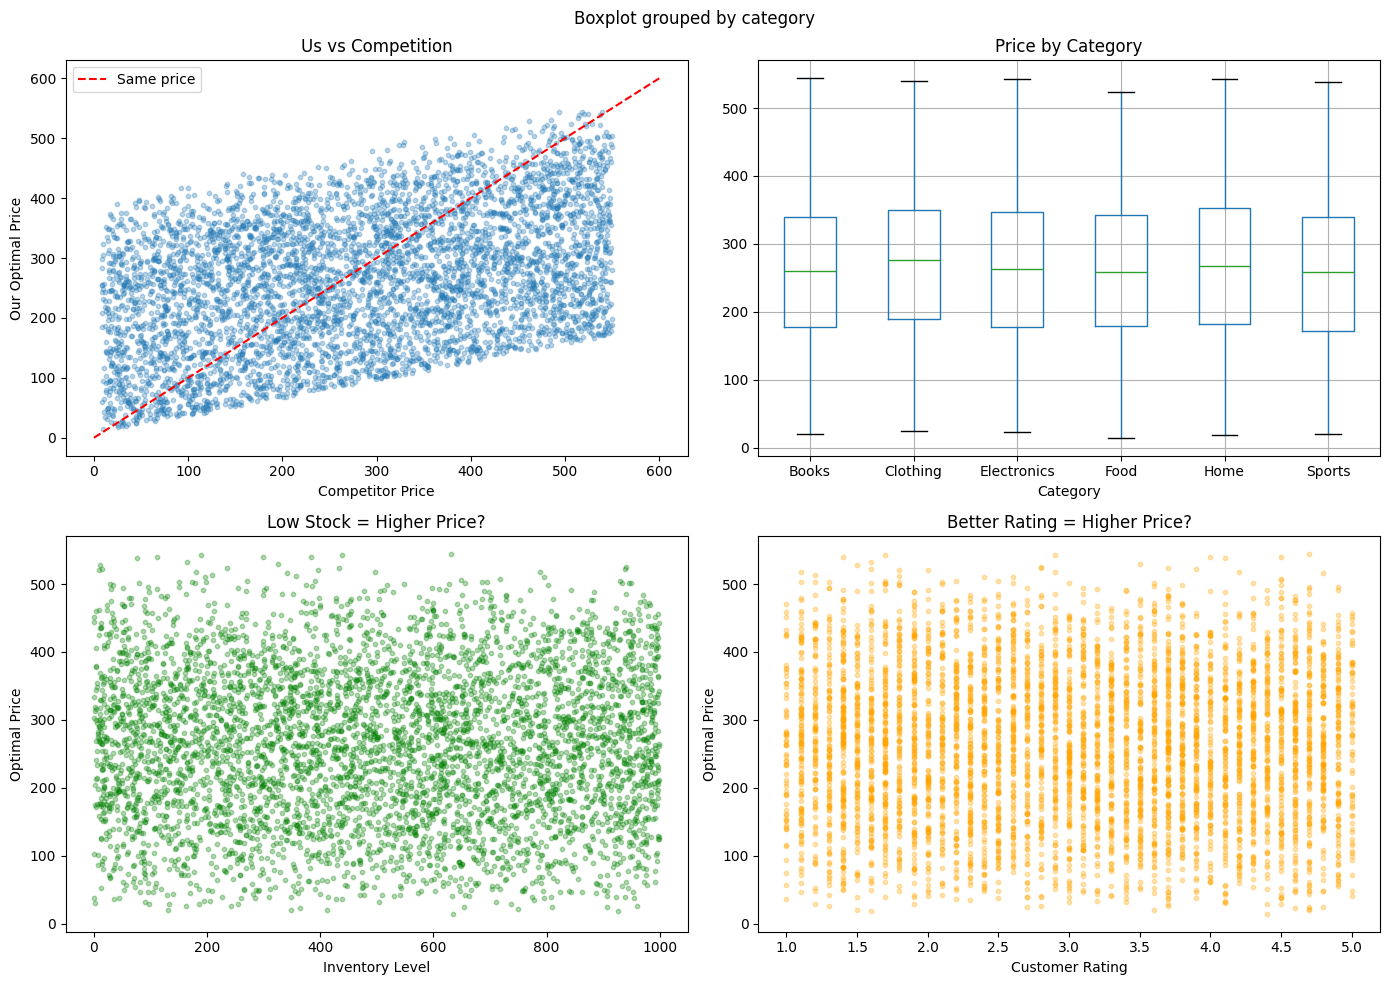

In [4]:
# Plot some stuff to understand pricing

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price vs competitor
axes[0,0].scatter(df['competitor_price'], df['optimal_price'], alpha=0.3, s=10)
axes[0,0].plot([0, 600], [0, 600], 'r--', label='Same price')
axes[0,0].set_xlabel('Competitor Price')
axes[0,0].set_ylabel('Our Optimal Price')
axes[0,0].set_title('Us vs Competition')
axes[0,0].legend()

# Price by category
df.boxplot(column='optimal_price', by='category', ax=axes[0,1])
axes[0,1].set_title('Price by Category')
axes[0,1].set_xlabel('Category')

# Inventory vs price
axes[1,0].scatter(df['inventory_level'], df['optimal_price'], alpha=0.3, s=10, c='green')
axes[1,0].set_xlabel('Inventory Level')
axes[1,0].set_ylabel('Optimal Price')
axes[1,0].set_title('Low Stock = Higher Price?')

# Rating vs price
axes[1,1].scatter(df['customer_rating'], df['optimal_price'], alpha=0.3, s=10, c='orange')
axes[1,1].set_xlabel('Customer Rating')
axes[1,1].set_ylabel('Optimal Price')
axes[1,1].set_title('Better Rating = Higher Price?')

plt.tight_layout()
plt.show()

In [5]:
# Models don't understand text, so convert categories to numbers
le = LabelEncoder()

df['category_num'] = le.fit_transform(df['category'])
df['product_num'] = le.fit_transform(df['product_id'])

print("Categories mapped:")
for i, cat in enumerate(le.classes_):
    print(f"  {cat} -> {i}")

Categories mapped:
  PROD_0000 -> 0
  PROD_0001 -> 1
  PROD_0002 -> 2
  PROD_0003 -> 3
  PROD_0004 -> 4
  PROD_0005 -> 5
  PROD_0006 -> 6
  PROD_0007 -> 7
  PROD_0008 -> 8
  PROD_0009 -> 9
  PROD_0010 -> 10
  PROD_0011 -> 11
  PROD_0012 -> 12
  PROD_0013 -> 13
  PROD_0014 -> 14
  PROD_0015 -> 15
  PROD_0016 -> 16
  PROD_0017 -> 17
  PROD_0018 -> 18
  PROD_0019 -> 19
  PROD_0020 -> 20
  PROD_0021 -> 21
  PROD_0022 -> 22
  PROD_0023 -> 23
  PROD_0024 -> 24
  PROD_0025 -> 25
  PROD_0026 -> 26
  PROD_0027 -> 27
  PROD_0028 -> 28
  PROD_0029 -> 29
  PROD_0030 -> 30
  PROD_0031 -> 31
  PROD_0032 -> 32
  PROD_0033 -> 33
  PROD_0034 -> 34
  PROD_0035 -> 35
  PROD_0036 -> 36
  PROD_0037 -> 37
  PROD_0038 -> 38
  PROD_0039 -> 39
  PROD_0040 -> 40
  PROD_0041 -> 41
  PROD_0042 -> 42
  PROD_0043 -> 43
  PROD_0044 -> 44
  PROD_0045 -> 45
  PROD_0046 -> 46
  PROD_0047 -> 47
  PROD_0048 -> 48
  PROD_0049 -> 49
  PROD_0050 -> 50
  PROD_0051 -> 51
  PROD_0052 -> 52
  PROD_0053 -> 53
  PROD_0054 -> 54
 

In [6]:
# What we'll use to predict
features = [
    'base_price', 'competitor_price', 'inventory_level',
    'days_in_stock', 'is_weekend', 'is_holiday',
    'customer_rating', 'review_count', 'demand_trend',
    'category_num', 'product_num'
]

target = 'optimal_price'

X = df[features]
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 4000, Test: 1000


In [7]:
# Random Forest for pricing
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# How'd we do?
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🎯 Random Forest Results:")
print(f"   MAE : ${mae:.2f} (avg error)")
print(f"   RMSE: ${rmse:.2f}")

# Example predictions
print("\nSample predictions:")
for i in range(5):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    diff = abs(actual - predicted)
    print(f"  Actual: ${actual:.2f} | Predicted: ${predicted:.2f} | Off by: ${diff:.2f}")

🎯 Random Forest Results:
   MAE : $4.60 (avg error)
   RMSE: $5.94

Sample predictions:
  Actual: $233.82 | Predicted: $238.63 | Off by: $4.81
  Actual: $288.52 | Predicted: $292.84 | Off by: $4.32
  Actual: $278.51 | Predicted: $280.85 | Off by: $2.34
  Actual: $142.19 | Predicted: $143.72 | Off by: $1.53
  Actual: $246.11 | Predicted: $254.56 | Off by: $8.45


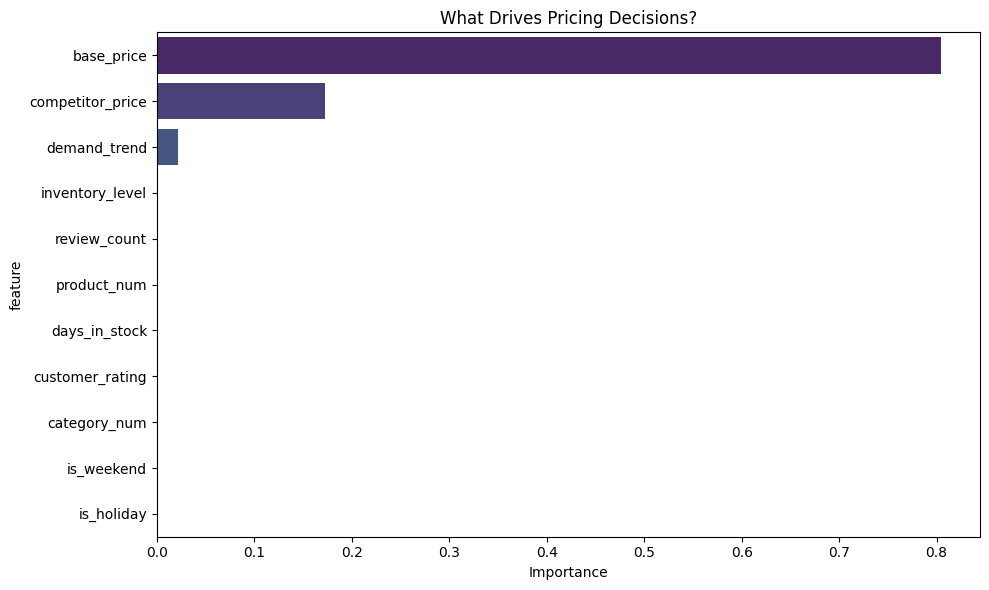

Competitor price and base price matter most. Makes sense!


In [8]:
# What matters most for pricing?
importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance, palette='viridis')
plt.title('What Drives Pricing Decisions?')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Competitor price and base price matter most. Makes sense!")

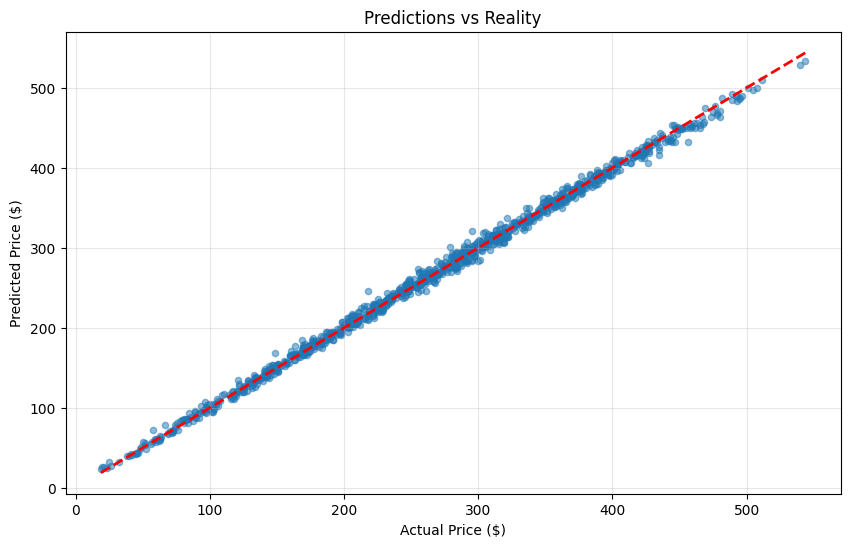

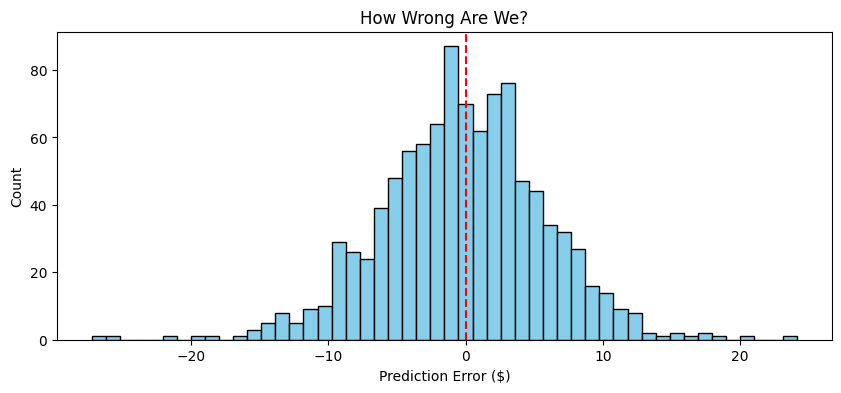

In [9]:
# Plot predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predictions vs Reality')
plt.grid(True, alpha=0.3)
plt.show()

# Error distribution
errors = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Count')
plt.title('How Wrong Are We?')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

In [10]:
try:
    import xgboost as xgb

    xg_model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )

    xg_model.fit(X_train, y_train)
    xg_pred = xg_model.predict(X_test)

    xg_mae = mean_absolute_error(y_test, xg_pred)
    print(f"🚀 XGBoost MAE: ${xg_mae:.2f}")
    print(f"   vs Random Forest: ${mae:.2f}")

    if xg_mae < mae:
        print("XGBoost wins! 🎉")
    else:
        print("Random Forest still better 🤷")

except ImportError:
    print("XGBoost not installed, skipping")

🚀 XGBoost MAE: $3.01
   vs Random Forest: $4.60
XGBoost wins! 🎉


In [ ]:
from google.colab import drive
drive.mount('/content/drive')